## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

from Bio.SeqUtils.ProtParam import ProteinAnalysis

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Cargar dataset

In [2]:
df = pd.read_csv("dataset.csv")

embeddings = np.load("protein_embeddings.npy")
pdl1_embedding = np.load("pdl1_embedding.npy")

print("Dataset shape:", df.shape)
print("Embeddings shape:", embeddings.shape)
print("PDL1 embedding:", pdl1_embedding.shape)

Dataset shape: (28800, 8)
Embeddings shape: (28800, 2560)
PDL1 embedding: (1280,)


## Separar embeddings del binder

In [3]:
binder_embeddings = embeddings[:, :1280]

print(binder_embeddings.shape)

(28800, 1280)


## Crear interaction features con PDL1

In [4]:
target_matrix = np.tile(pdl1_embedding, (binder_embeddings.shape[0], 1))

interaction_features = np.concatenate([
    binder_embeddings,
    np.abs(binder_embeddings - target_matrix),
    binder_embeddings * target_matrix
], axis=1)

print("Interaction features shape:", interaction_features.shape)

Interaction features shape: (28800, 3840)


## Features biofísicas del péptido

In [5]:
def clean_peptide(seq):
    return seq.split("/")[0]

def peptide_features(seq):

    peptide = clean_peptide(seq)

    analysis = ProteinAnalysis(peptide)

    return [
        len(peptide),
        analysis.gravy(),
        analysis.aromaticity(),
        analysis.isoelectric_point(),
        analysis.molecular_weight(),
        analysis.instability_index()
    ]

bio_features = np.array([
    peptide_features(seq) for seq in df["seq"]
])

print("Bio features shape:", bio_features.shape)

Bio features shape: (28800, 6)


## Combinar features

In [6]:
X = np.concatenate([
    interaction_features,
    bio_features
], axis=1)

print("Total feature shape:", X.shape)

Total feature shape: (28800, 3846)


## Targets de regresión

In [7]:
y = df[["ptm","i_ptm"]].values

print("Targets shape:", y.shape)

Targets shape: (28800, 2)


## Train / Test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Escalado de features

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA (solo sobre el binder)

In [10]:
binder_block_train = X_train_scaled[:, :1280]
binder_block_test = X_test_scaled[:, :1280]

pca = PCA(n_components=200)

binder_pca_train = pca.fit_transform(binder_block_train)
binder_pca_test = pca.transform(binder_block_test)

X_train_pca = np.concatenate([
    binder_pca_train,
    X_train_scaled[:,1280:]
], axis=1)

X_test_pca = np.concatenate([
    binder_pca_test,
    X_test_scaled[:,1280:]
], axis=1)

print(X_train_pca.shape)

(23040, 2766)


## Función de métricas

In [11]:
def regression_metrics(y_true, y_pred, name):

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)

## Modelo 1 — XGBoost Regressor

In [12]:
model_ptm = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist"
)

model_iptm = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist"
)

model_ptm.fit(X_train_pca, y_train[:,0])
model_iptm.fit(X_train_pca, y_train[:,1])

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Evaluación XGBoost

In [13]:
pred_ptm = model_ptm.predict(X_test_pca)
pred_iptm = model_iptm.predict(X_test_pca)

regression_metrics(y_test[:,0], pred_ptm, "PTM")
regression_metrics(y_test[:,1], pred_iptm, "iPTM")


PTM
MSE: 0.0009074895945193395
MAE: 0.01897877304785781
R2: 0.3167095524292607

iPTM
MSE: 0.015556866187386264
MAE: 0.07137145262265371
R2: 0.7139404206884281


## Gráfica Predicción vs Real

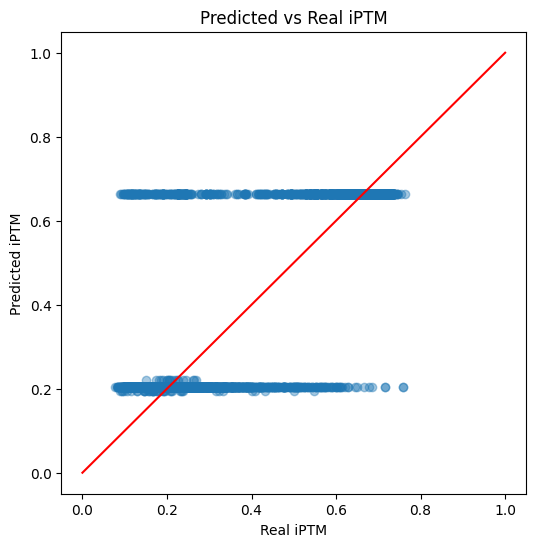

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test[:,1], pred_iptm, alpha=0.4)

plt.xlabel("Real iPTM")
plt.ylabel("Predicted iPTM")

plt.plot([0,1],[0,1], color="red")

plt.title("Predicted vs Real iPTM")

plt.show()

## Random Forest

In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

rf_pred = rf.predict(X_test_pca)

regression_metrics(y_test[:,0], rf_pred[:,0], "RF PTM")
regression_metrics(y_test[:,1], rf_pred[:,1], "RF iPTM")


RF PTM
MSE: 0.0010537803116442213
MAE: 0.01809976993779512
R2: 0.20656057641521697

RF iPTM
MSE: 0.01664593291420275
MAE: 0.07121586551482174
R2: 0.6939146670460941


## Dataset para red neuronal

In [16]:
class ProteinDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## DataLoaders

In [17]:
train_dataset = ProteinDataset(X_train_pca, y_train)
test_dataset = ProteinDataset(X_test_pca, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

## Red neuronal multitask

In [18]:
class MLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,2)
        )

    def forward(self,x):
        return self.net(x)

## Entrenamiento

In [19]:
model = MLP(X_train_pca.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.MSELoss()

epochs = 25

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)

    print("Epoch",epoch,"Loss:",total_loss)

Epoch 0 Loss: 12.144594058860093
Epoch 1 Loss: 1.8015958876349032
Epoch 2 Loss: 1.6381327593699098
Epoch 3 Loss: 1.5563491540960968
Epoch 4 Loss: 1.5382380881346762
Epoch 5 Loss: 1.5286608070600778
Epoch 6 Loss: 1.5289242719300091
Epoch 7 Loss: 1.4884522813372314
Epoch 8 Loss: 1.5095111173577607
Epoch 9 Loss: 1.5119222006760538
Epoch 10 Loss: 1.4914691955782473
Epoch 11 Loss: 1.5144635499455035
Epoch 12 Loss: 1.482923889765516
Epoch 13 Loss: 1.4831810877658427
Epoch 14 Loss: 1.4996626842767
Epoch 15 Loss: 1.470096796285361
Epoch 16 Loss: 1.46344538545236
Epoch 17 Loss: 1.4629242643713951
Epoch 18 Loss: 1.4258610573597252
Epoch 19 Loss: 1.4210353288799524
Epoch 20 Loss: 1.4409693065099418
Epoch 21 Loss: 1.4284886014647782
Epoch 22 Loss: 1.4037307566031814
Epoch 23 Loss: 1.4321611025370657
Epoch 24 Loss: 1.4256581184454262


## Curva de entrenamiento

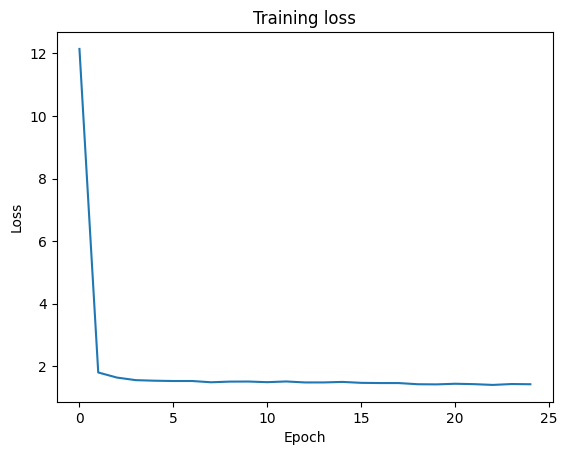

In [20]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training loss")

plt.show()

## Evaluación red neuronal

In [21]:
model.eval()

preds = []
targets = []

with torch.no_grad():

    for X_batch,y_batch in test_loader:

        outputs = model(X_batch)

        preds.append(outputs.numpy())
        targets.append(y_batch.numpy())

preds = np.vstack(preds)
targets = np.vstack(targets)

regression_metrics(targets[:,0], preds[:,0], "NN PTM")
regression_metrics(targets[:,1], preds[:,1], "NN iPTM")


NN PTM
MSE: 0.015579762868583202
MAE: 0.1106579452753067
R2: -10.730716705322266

NN iPTM
MSE: 0.01451131235808134
MAE: 0.08013565838336945
R2: 0.7331660389900208


## Gráfica final iPTM

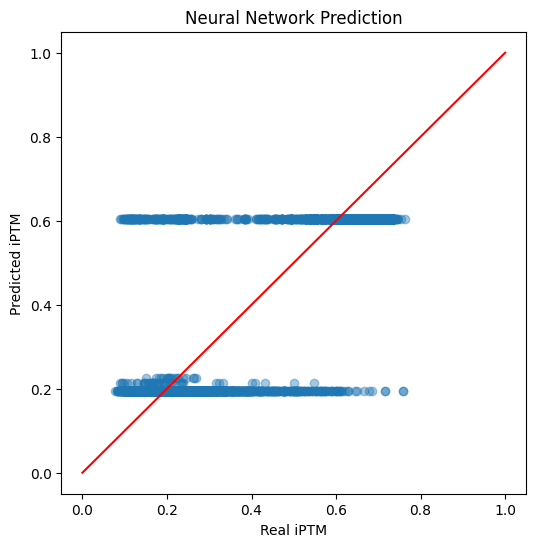

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(targets[:,1], preds[:,1], alpha=0.4)

plt.xlabel("Real iPTM")
plt.ylabel("Predicted iPTM")

plt.plot([0,1],[0,1], color="red")

plt.title("Neural Network Prediction")

plt.show()